# DEG20 Downstream Experiment

多条件版 DEG downstream 实验。这个 notebook 直接消费现有 full-gene `pkl`，不重新训练模型。

核心定义：
- 当前默认真实 DE：`truth_deg_mode = effect_size_non_dropout`。
- 当前默认预测 DE：`pred_deg_mode = effect_size_non_dropout`。
- 当前默认 top-k：`n_degs = 100`。
- 主指标仍沿用 `common_degs_at_20 / jaccard_at_20 / precision_at_20 / recall_at_20` 这些历史列名，但在当前默认设置下它们实际对应的是 top100 分析结果。

默认推荐：
- 当前推荐：`truth_deg_mode = "effect_size_non_dropout"`
- `truth_deg_mode = "scanpy"` ?? `Truth_full vs Ctrl_full` ? Scanpy ?????? `DEG20`
- `truth_deg_mode = "effect_size"` ?? `|mu_truth - mu_ctrl| + top-k` ???? `DE`
- `truth_deg_mode = "effect_size_non_dropout"` 可按 `|mu_truth - mu_ctrl| + non-dropout + 去掉 perturb gene + top-k` 生成真实 DE。
- `truth_deg_mode = "ttest_non_dropout"` 可按 `Truth_full vs Ctrl_full` 的 `t-test + non-dropout + 去掉 perturb gene + top-k` 生成真实 DE。
- 当前推荐：`pred_deg_mode = "effect_size_non_dropout"`
- `pred_deg_mode = "ttest_non_dropout"` 可按和真实 DE 更接近的口径生成预测 DE。
- `pred_deg_mode = "effect_size_non_dropout"` 可按 `|mu_pred - mu_ctrl| + non-dropout + 去掉 perturb gene + top-k` 生成预测 DE。
- `enrichment_mode = "export_only"`
- 当前推荐：`n_degs = 100`，即默认使用 DEGs top100。
- `variant_tag = "nearest"` 仅在 `model_name="trishift"` 且目标产物是 `trishift_*_nearest.pkl` 时需要设置

- ? `payload` ?????? `artifacts/cache/degs/` ?????? truth DEG pkl ???????? `<dataset>_degs.pkl`


In [150]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.deg20_experiment as deg20_experiment
importlib.reload(deg20_experiment)

run_deg20_experiment = deg20_experiment.run_deg20_experiment
load_condition_payload = deg20_experiment.load_condition_payload
summarize_condition_payload = deg20_experiment.summarize_condition_payload
build_mean_var_scatter = deg20_experiment.build_mean_var_scatter

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
repo_root


WindowsPath('e:/CODE/trishift')

## Parameters

设置一个模型、一个数据集，以及要分析的 split。


In [151]:
dataset = "adamson"
model_name = "genepert"  # trishift | gears | genepert | scouter
split_ids = [1]
result_dir = None  # 可手动覆盖结果目录
out_root = None  # 可手动覆盖 notebook 输出目录
variant_tag = ""  # trishift ??: nearest / random / None
focus_conditions = []  # 例如 ["ATP5B+ctrl", "BHLHE40+ctrl"]
truth_deg_mode = "effect_size_non_dropout"  # payload | scanpy | effect_size | effect_size_non_dropout | ttest_non_dropout
pred_deg_mode =  "effect_size_non_dropout"  # adaptive | scanpy | effect_size | effect_size_non_dropout | ttest_non_dropout
n_degs = 100  # 当前默认使用 truth/pred DEGs top100
enrichment_mode = "export_only"  # export_only | run_if_available | disabled
enrichment_library = "Reactome_2022"
remove_perturbed_genes = True

run_kwargs = dict(
    dataset=dataset,
    model_name=model_name,
    split_ids=split_ids,
    result_dir=result_dir,
    out_root=out_root,
    variant_tag=variant_tag,
    focus_conditions=focus_conditions or None,
    truth_deg_mode=truth_deg_mode,
    pred_deg_mode=pred_deg_mode,
    n_degs=n_degs,
    enrichment_mode=enrichment_mode,
    enrichment_library=enrichment_library,
    remove_perturbed_genes=remove_perturbed_genes,
)
run_kwargs


{'dataset': 'adamson',
 'model_name': 'genepert',
 'split_ids': [1],
 'result_dir': None,
 'out_root': None,
 'variant_tag': '',
 'focus_conditions': None,
 'truth_deg_mode': 'effect_size_non_dropout',
 'pred_deg_mode': 'effect_size_non_dropout',
 'n_degs': 100,
 'enrichment_mode': 'export_only',
 'enrichment_library': 'Reactome_2022',
 'remove_perturbed_genes': True}

In [152]:
result = run_deg20_experiment(**run_kwargs)
print(f"out_dir: {result.out_dir}")
display(result.dataset_summary_df)
display(result.split_summary_df)
display(result.per_condition_df.head(20))


d:\conda_envs\scouter\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\conda_envs\scouter\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\conda_envs\scouter\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\conda_envs\scouter\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\conda_envs\scouter\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\conda_envs\scouter\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\conda_envs\scouter\lib\site-packages\numpy\lib\_function_base_impl.py:292

out_dir: E:\CODE\trishift\artifacts\results\genepert\adamson\deg20_downstream_20260316_015638


d:\conda_envs\scouter\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,model_name,dataset,deg_top_k,n_splits,common_degs_at_20_mean,common_degs_at_20_median,jaccard_at_20_mean,jaccard_at_20_median,precision_at_20_mean,precision_at_20_median,recall_at_20_mean,recall_at_20_median,truth_deg_count_mean,truth_deg_count_median,pred_deg_count_mean,pred_deg_count_median,scpram_r2_degs_mean_mean_mean,scpram_r2_degs_mean_mean_median,scpram_r2_degs_var_mean_mean,scpram_r2_degs_var_mean_median,scpram_wasserstein_degs_sum_mean,scpram_wasserstein_degs_sum_median
0,genepert,adamson,100,1,19.058824,19.0,1.0,1.0,1.0,1.0,1.0,1.0,19.058824,19.0,19.058824,19.0,0.948,0.981155,NaN,NaN,7.614977,5.859769


,model_name,dataset,split_id,deg_top_k,n_conditions,n_scanpy_rank,n_effect_size_fallback,common_degs_at_20_mean,common_degs_at_20_median,jaccard_at_20_mean,jaccard_at_20_median,precision_at_20_mean,precision_at_20_median,recall_at_20_mean,recall_at_20_median,truth_deg_count_mean,truth_deg_count_median,pred_deg_count_mean,pred_deg_count_median,scpram_r2_degs_mean_mean_mean,scpram_r2_degs_mean_mean_median,scpram_r2_degs_var_mean_mean,scpram_r2_degs_var_mean_median,scpram_wasserstein_degs_sum_mean,scpram_wasserstein_degs_sum_median
0,genepert,adamson,1,100,17,0,0,19.058824,19.0,1.0,1.0,1.0,1.0,1.0,1.0,19.058824,19.0,19.058824,19.0,0.948,0.981155,NaN,NaN,7.614977,5.859769


,model_name,dataset,split_id,condition,focus_key,pkl_path,deg_top_k,truth_deg_mode_used,pred_deg_mode_used,common_degs_at_20,jaccard_at_20,precision_at_20,recall_at_20,truth_deg_count,pred_deg_count,scpram_r2_degs_mean_mean,scpram_r2_degs_var_mean,scpram_wasserstein_degs_sum
0,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.988545,NaN,5.859769
1,genepert,adamson,1,BHLHE40+ctrl,1:BHLHE40+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.846780,NaN,16.056035
2,genepert,adamson,1,CARS+ctrl,1:CARS+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.745679,NaN,14.067619
3,genepert,adamson,1,CCND3+ctrl,1:CCND3+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.953934,NaN,7.265281
4,genepert,adamson,1,COPB1+ctrl,1:COPB1+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,20,1.0,1.0,1.0,20,20,0.979695,NaN,7.486604
5,genepert,adamson,1,DERL2+ctrl,1:DERL2+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.992137,NaN,5.743588
6,genepert,adamson,1,HARS+ctrl,1:HARS+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.856542,NaN,12.252470
7,genepert,adamson,1,HYOU1+ctrl,1:HYOU1+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.993446,NaN,5.344139
8,genepert,adamson,1,MANF+ctrl,1:MANF+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.993218,NaN,5.414610
9,genepert,adamson,1,MRPL39+ctrl,1:MRPL39+ctrl,E:\CODE\trishift\artifacts\results\genepert\ad...,100,effect_size_non_dropout,effect_size_non_dropout,19,1.0,1.0,1.0,19,19,0.982068,NaN,5.808479


## Metric Distributions

这里先看每个 condition 的 overlap / regression / Wasserstein 指标分布。


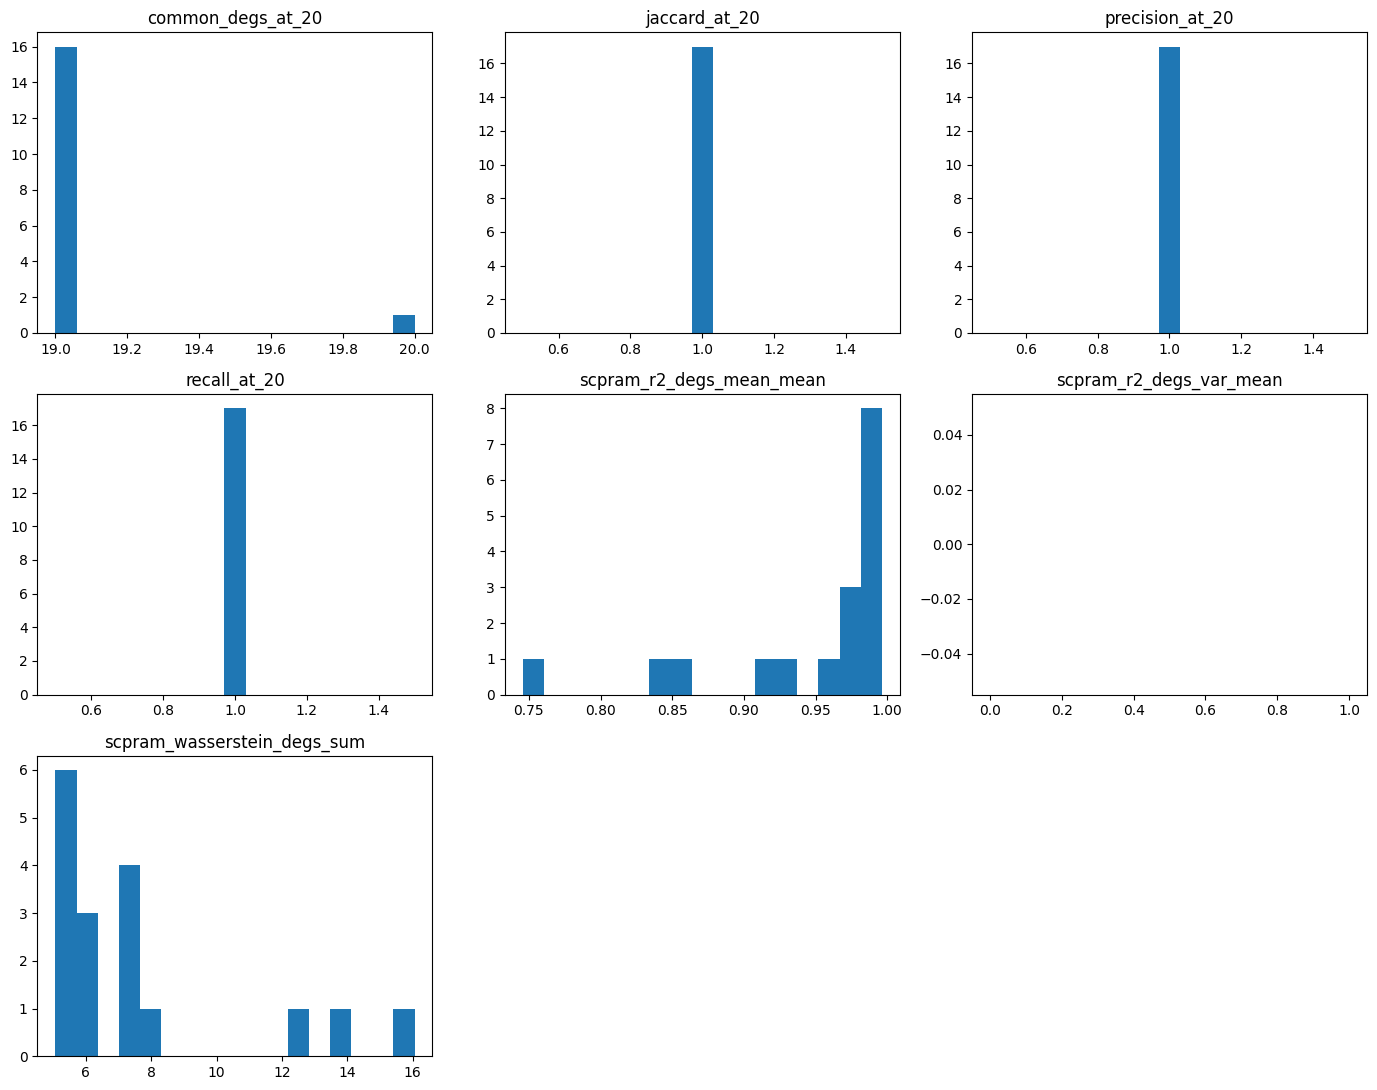

,count,mean,std,min,25%,50%,75%,max
common_degs_at_20,17.0,19.058824,0.242536,19.000000,19.000000,19.000000,19.000000,20.000000
jaccard_at_20,17.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
precision_at_20,17.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
recall_at_20,17.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
scpram_r2_degs_mean_mean,17.0,0.948000,0.070144,0.745679,0.927716,0.981155,0.993218,0.996208
scpram_r2_degs_var_mean,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scpram_wasserstein_degs_sum,17.0,7.614977,3.310718,5.070861,5.530938,5.859769,7.527088,16.056035


In [153]:
metric_cols = [
    "common_degs_at_20",
    "jaccard_at_20",
    "precision_at_20",
    "recall_at_20",
    "scpram_r2_degs_mean_mean",
    "scpram_r2_degs_var_mean",
    "scpram_wasserstein_degs_sum",
]
plot_df = result.per_condition_df[metric_cols].apply(pd.to_numeric, errors="coerce")
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for ax, col in zip(axes, metric_cols):
    vals = plot_df[col].dropna()
    ax.hist(vals, bins=min(20, max(5, len(vals))))
    ax.set_title(col)
for ax in axes[len(metric_cols):]:
    ax.axis("off")
fig.tight_layout()
plt.show()

display(result.per_condition_df[metric_cols].describe().T)


## Representative Conditions

默认会自动挑 overlap 最好 / 中位 / 最差的 3 个 condition；如果你在参数里填了 `focus_conditions`，这里就按你指定的 condition 展示。


In [154]:
rep_cols = [
    "split_id",
    "condition",
    "truth_deg_mode_used",
    "pred_deg_mode_used",
    "common_degs_at_20",
    "jaccard_at_20",
    "scpram_r2_degs_mean_mean",
    "scpram_r2_degs_var_mean",
    "scpram_wasserstein_degs_sum",
]
display(result.representative_df[rep_cols])


,split_id,condition,truth_deg_mode_used,pred_deg_mode_used,common_degs_at_20,jaccard_at_20,scpram_r2_degs_mean_mean,scpram_r2_degs_var_mean,scpram_wasserstein_degs_sum
0,1,COPB1+ctrl,effect_size_non_dropout,effect_size_non_dropout,20,1.0,0.979695,NaN,7.486604
1,1,MRPL39+ctrl,effect_size_non_dropout,effect_size_non_dropout,19,1.0,0.982068,NaN,5.808479
2,1,CARS+ctrl,effect_size_non_dropout,effect_size_non_dropout,19,1.0,0.745679,NaN,14.067619



=== split 1 | COPB1+ctrl ===


,truth_deg_top100,pred_deg_top100,common_deg_top100
0,TIMP1,RPS29,RPS29
1,SH3BGRL3,SH3BGRL3,SH3BGRL3
2,MAT2A,RPS21,RPS21
3,EMP3,MAT2A,MAT2A
4,RPS29,TIMP1,TIMP1
5,RP11-301G19.1,RPS28,RPS28
6,RPS21,RPL37A,RPL37A
7,B2M,RPL37,RPL37
8,RPL37A,B2M,B2M
9,STXBP6,RPS12,RPS12


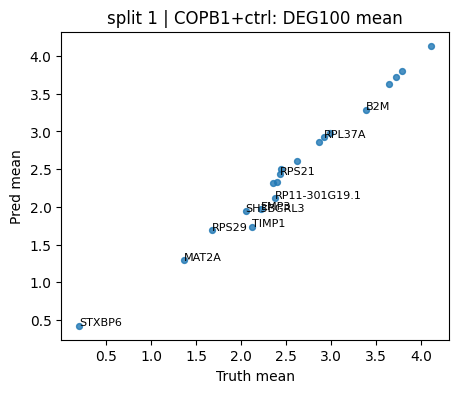

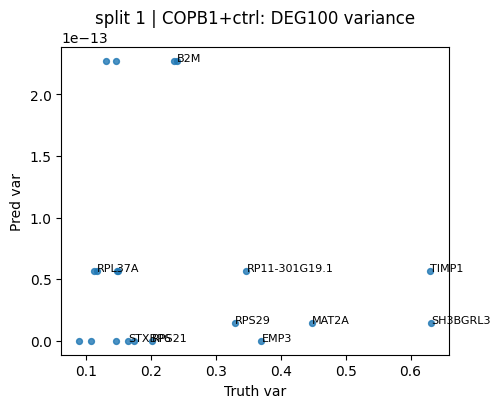


=== split 1 | MRPL39+ctrl ===


,truth_deg_top100,pred_deg_top100,common_deg_top100
0,APOE,RPS29,RPS29
1,RPS29,RPS21,RPS21
2,RPS21,RPS28,RPS28
3,SDF2L1,MS4A3,MS4A3
4,RPL37A,RPL37A,RPL37A
5,RPS28,RPL37,RPL37
6,RPS27,B2M,B2M
7,MS4A3,CD63,CD63
8,CD63,ALDOA,ALDOA
9,RPL37,RPS12,RPS12


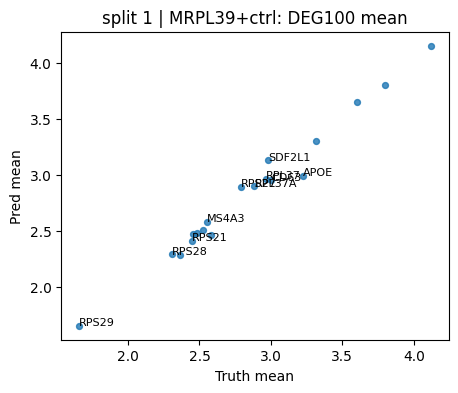

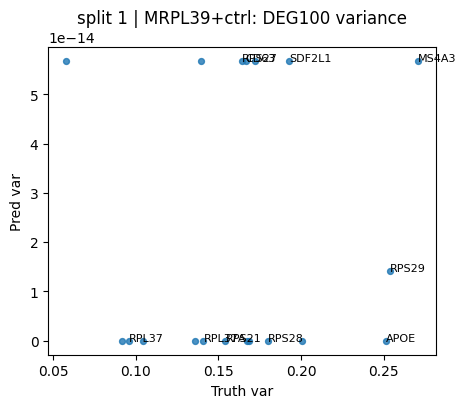


=== split 1 | CARS+ctrl ===


,truth_deg_top100,pred_deg_top100,common_deg_top100
0,HBZ,HBZ,HBZ
1,SH3BGRL3,SH3BGRL3,SH3BGRL3
2,HBA1,HBA1,HBA1
3,GAL,RPS21,RPS21
4,MS4A4A,RPS28,RPS28
5,PHGDH,TIMP1,TIMP1
6,PTMA,IFITM2,IFITM2
7,IFITM2,B2M,B2M
8,TIMP1,CD63,CD63
9,MALAT1,GAL,GAL


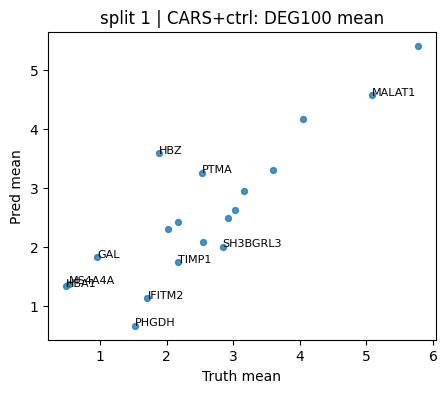

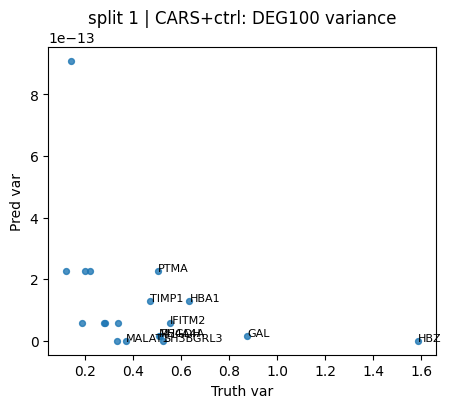

In [155]:
for row in result.representative_df.to_dict(orient="records"):
    split_id = int(row["split_id"])
    condition = str(row["condition"])
    payload_item = load_condition_payload(
        model_name=model_name,
        dataset=dataset,
        split_id=split_id,
        condition=condition,
        result_dir=result_dir,
        variant_tag=variant_tag,
    )
    detail = summarize_condition_payload(
        payload_item=payload_item,
        condition=condition,
        truth_deg_mode=truth_deg_mode,
        pred_deg_mode=pred_deg_mode,
        remove_perturbed_genes=remove_perturbed_genes,
        n_degs=n_degs,
    )
    print(f"\n=== split {split_id} | {condition} ===")
    display(
        pd.DataFrame(
            {
                f"truth_deg_top{n_degs}": pd.Series(detail["truth_deg20"]),
                f"pred_deg_top{n_degs}": pd.Series(detail["pred_deg20"]),
                f"common_deg_top{n_degs}": pd.Series(detail["common_deg20"]),
            }
        )
    )
    fig_mean, fig_var = build_mean_var_scatter(
        payload_item=payload_item,
        truth_deg_idx=detail["truth_deg_idx"],
        title_prefix=f"split {split_id} | {condition}",
        n_degs=n_degs,
    )
    plt.show(fig_mean)
    plt.show(fig_var)
    plt.close(fig_mean)
    plt.close(fig_var)


## Exported Gene Lists

主流程默认总会导出三类 gene list：`truth_deg20` / `pred_deg20` / `common_deg20`。


In [156]:
display(result.gene_lists_df.head(30))
print(result.out_dir / "deg_gene_lists_long.csv")


,model_name,dataset,split_id,condition,focus_key,list_type,rank,gene,deg_top_k,truth_deg_mode_used,pred_deg_mode_used
0,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,1,RPS29,100,effect_size_non_dropout,effect_size_non_dropout
1,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,2,RPS21,100,effect_size_non_dropout,effect_size_non_dropout
2,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,3,RPS28,100,effect_size_non_dropout,effect_size_non_dropout
3,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,4,RPL37A,100,effect_size_non_dropout,effect_size_non_dropout
4,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,5,MS4A3,100,effect_size_non_dropout,effect_size_non_dropout
5,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,6,B2M,100,effect_size_non_dropout,effect_size_non_dropout
6,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,7,RPL37,100,effect_size_non_dropout,effect_size_non_dropout
7,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,8,CD63,100,effect_size_non_dropout,effect_size_non_dropout
8,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,9,RPS12,100,effect_size_non_dropout,effect_size_non_dropout
9,genepert,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,10,ERP29,100,effect_size_non_dropout,effect_size_non_dropout


E:\CODE\trishift\artifacts\results\genepert\adamson\deg20_downstream_20260316_015638\deg_gene_lists_long.csv


## Optional Enrichment

当 `enrichment_mode="run_if_available"` 且环境里有 `gseapy` 时，这里会显示 enrichment 结果；否则 notebook 只保留 gene list 导出。


In [157]:
if result.enrichment_df.empty:
    print("No enrichment results. This is expected when enrichment_mode='export_only' or gseapy is unavailable.")
else:
    display(result.enrichment_df.head(30))


No enrichment results. This is expected when enrichment_mode='export_only' or gseapy is unavailable.


## Notes

- `common_degs_at_20` 和 `jaccard_at_20` 这两个列名保留了历史命名，但在当前 notebook 默认设置下它们实际对应的是 top100 overlap。
- `scpram_r2_degs_mean_mean` / `scpram_r2_degs_var_mean` 更接近 scPRAM 论文里 DEG mean/variance regression 的思想。
- `scpram_wasserstein_degs_sum` 越低越好，表示预测和真实在当前 DEG top100 子空间上的分布差更小。
